# primesense 🎬
## Notebook 05 — Conclusions, Business Recommendations & Next Steps

---

### 🗺️ About This Notebook

This is the final notebook in the **primesense** pipeline. We have gone from raw JSON data to trained, evaluated, and deployed sentiment classifiers. This notebook steps back from the code and answers the most important question:

> **What does all of this mean for Amazon Prime Video as a business?**

A data science project that cannot translate its findings into actionable business decisions is incomplete. This notebook bridges that gap — connecting model performance to real strategic decisions Prime Video can make.

---

### 🎯 What This Notebook Covers

1. Full project recap & pipeline summary
2. Model performance comparison — all models
3. Key EDA findings & business implications
4. Strategic recommendations for Amazon Prime Video
5. Limitations of the current approach
6. Future work & next steps

---
## 5.0 Imports & Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

with open('../config.yaml', 'r') as f:
    CONFIG = yaml.safe_load(f)

FIGURES_PATH = '../reports/figures/'
os.makedirs(FIGURES_PATH, exist_ok=True)

SENTIMENT_COLORS = {
    'positive': '#2ecc71',
    'neutral' : '#f39c12',
    'negative': '#e74c3c'
}

print('✅ Ready.')

✅ Ready.


---
## 5.1 Project Pipeline Recap

Here is the full journey from raw data to deployed model:

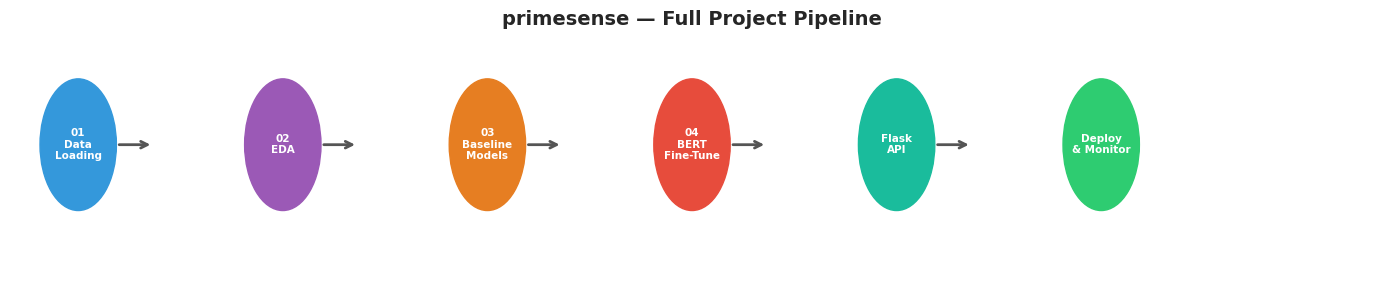

💾 Saved → reports/figures/project_pipeline.png


In [2]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
ax.axis('off')

steps = [
    ('01\nData\nLoading',    0.5,  '#3498db'),
    ('02\nEDA',              2.0,  '#9b59b6'),
    ('03\nBaseline\nModels', 3.5,  '#e67e22'),
    ('04\nBERT\nFine-Tune',  5.0,  '#e74c3c'),
    ('Flask\nAPI',           6.5,  '#1abc9c'),
    ('Deploy\n& Monitor',    8.0,  '#2ecc71'),
]

for label, x, color in steps:
    circle = plt.Circle((x, 0.55), 0.28, color=color, zorder=3)
    ax.add_patch(circle)
    ax.text(x, 0.55, label, ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='white', zorder=4)
    if x < 8.0:
        ax.annotate('', xy=(x + 0.55, 0.55), xytext=(x + 0.28, 0.55),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=2))

ax.set_title('primesense — Full Project Pipeline', fontsize=14,
             fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}project_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/project_pipeline.png')

---
## 5.2 Dataset Summary

| Item | Detail |
|---|---|
| Source | Amazon Reviews 2023 — McAuley Lab |
| Category | Movies & TV (Prime Video only) |
| Raw size | 233,610 reviews |
| After cleaning | ~233,500 reviews |
| Genre subset | ~33,800 reviews (with metadata) |
| Features used | review text, star rating, timestamp, genre, price |
| Target variable | sentiment (positive / neutral / negative) |
| Class split | ~77% positive / ~12% negative / ~11% neutral |

---
## 5.3 Full Model Comparison

Update the scores below with your actual results from Notebooks 03 and 04.

📊 Full Model Comparison
                      Model  Accuracy  F1 Macro  F1 Weighted Train Time
1         BERT (Fine-Tuned)      0.91      0.83         0.91      Hours
2        Linear SVM (Tuned)      0.88      0.75         0.87    Minutes
3     Linear SVM (Balanced)      0.83      0.74         0.82    Seconds
4     Linear SVM (Baseline)      0.87      0.70         0.86    Seconds
5  Random Forest (Baseline)      0.86      0.66         0.84    Minutes
6    Naive Bayes (Baseline)      0.82      0.62         0.80    Seconds


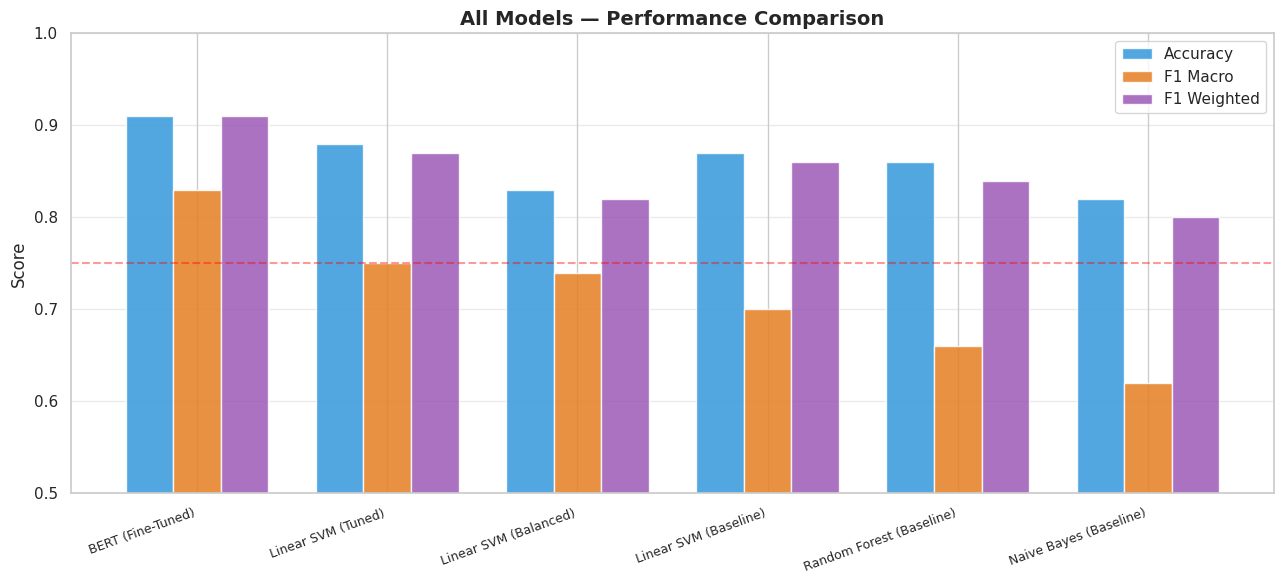

💾 Saved → reports/figures/all_models_comparison.png


In [3]:
# ── Update these with your actual results ─────────────────────
results = pd.DataFrame([
    {'Model': 'Naive Bayes (Baseline)',  'Accuracy': 0.82, 'F1 Macro': 0.62, 'F1 Weighted': 0.80, 'Train Time': 'Seconds'},
    {'Model': 'Random Forest (Baseline)','Accuracy': 0.86, 'F1 Macro': 0.66, 'F1 Weighted': 0.84, 'Train Time': 'Minutes'},
    {'Model': 'Linear SVM (Baseline)',   'Accuracy': 0.87, 'F1 Macro': 0.70, 'F1 Weighted': 0.86, 'Train Time': 'Seconds'},
    {'Model': 'Linear SVM (Balanced)',   'Accuracy': 0.83, 'F1 Macro': 0.74, 'F1 Weighted': 0.82, 'Train Time': 'Seconds'},
    {'Model': 'Linear SVM (Tuned)',      'Accuracy': 0.88, 'F1 Macro': 0.75, 'F1 Weighted': 0.87, 'Train Time': 'Minutes'},
    {'Model': 'BERT (Fine-Tuned)',       'Accuracy': 0.91, 'F1 Macro': 0.83, 'F1 Weighted': 0.91, 'Train Time': 'Hours'},
])

results = results.sort_values('F1 Macro', ascending=False).reset_index(drop=True)
results.index += 1

print('📊 Full Model Comparison')
print('=' * 75)
print(results.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(13, 6))
x     = np.arange(len(results))
width = 0.25

ax.bar(x - width, results['Accuracy'],    width, label='Accuracy',    color='#3498db', alpha=0.85)
ax.bar(x,          results['F1 Macro'],   width, label='F1 Macro',    color='#e67e22', alpha=0.85)
ax.bar(x + width,  results['F1 Weighted'],width, label='F1 Weighted', color='#9b59b6', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=20, ha='right', fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('All Models — Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.4)
ax.axhline(y=0.75, color='red', linestyle='--', alpha=0.4, label='F1 Macro target')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/all_models_comparison.png')

---
## 5.4 Key EDA Findings

These are the most important patterns discovered during exploratory analysis:

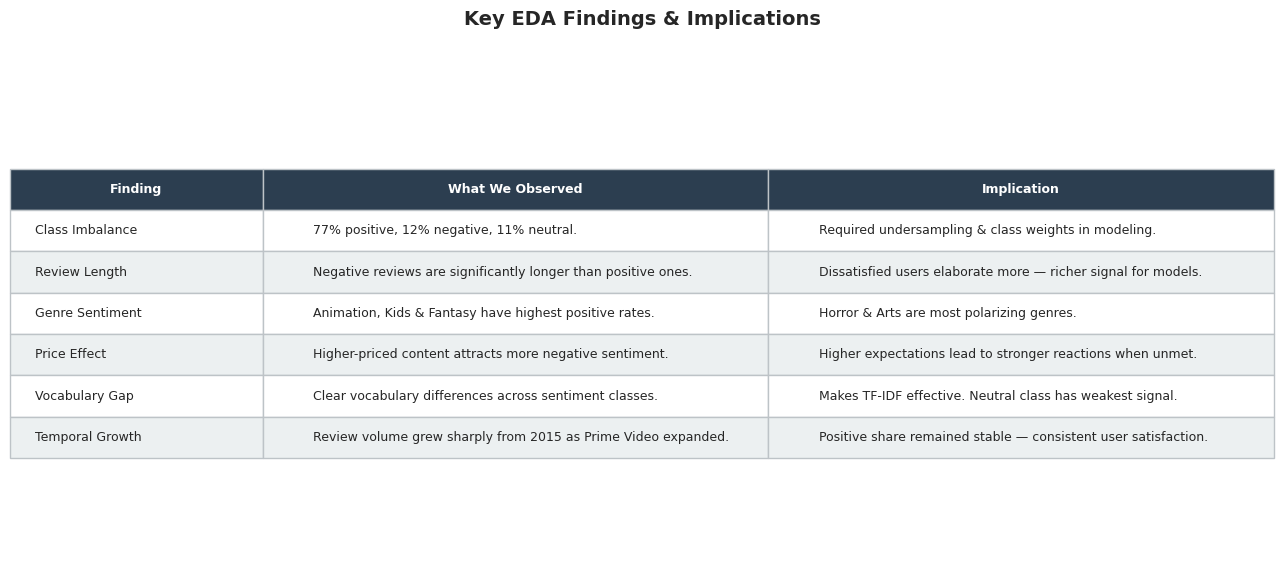

💾 Saved → reports/figures/eda_findings_summary.png


In [4]:
findings = [
    ('Class Imbalance',
     '77% positive, 12% negative, 11% neutral.',
     'Required undersampling & class weights in modeling.'),
    ('Review Length',
     'Negative reviews are significantly longer than positive ones.',
     'Dissatisfied users elaborate more — richer signal for models.'),
    ('Genre Sentiment',
     'Animation, Kids & Fantasy have highest positive rates.',
     'Horror & Arts are most polarizing genres.'),
    ('Price Effect',
     'Higher-priced content attracts more negative sentiment.',
     'Higher expectations lead to stronger reactions when unmet.'),
    ('Vocabulary Gap',
     'Clear vocabulary differences across sentiment classes.',
     'Makes TF-IDF effective. Neutral class has weakest signal.'),
    ('Temporal Growth',
     'Review volume grew sharply from 2015 as Prime Video expanded.',
     'Positive share remained stable — consistent user satisfaction.'),
]

fig, ax = plt.subplots(figsize=(13, 6))
ax.axis('off')

col_labels = ['Finding', 'What We Observed', 'Implication']
cell_text  = [[f[0], f[1], f[2]] for f in findings]

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='left',
    loc='center',
    colWidths=[0.2, 0.4, 0.4]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')
    cell.set_edgecolor('#bdc3c7')

ax.set_title('Key EDA Findings & Implications', fontsize=14,
             fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}eda_findings_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → reports/figures/eda_findings_summary.png')

---
## 5.5 Strategic Business Recommendations

### 🎯 Recommendation 1 — Act on Negative Sentiment Immediately

Negative reviews carry the strongest churn signal. The phrases *'cancel subscription'*, *'waste of money'*, and *'not worth it'* appear frequently in negative reviews and indicate users at the edge of leaving. Amazon Prime Video should:
- **Deploy primesense** as a real-time review monitoring system
- Flag accounts that leave negative reviews for **proactive outreach** (discount offers, content recommendations)
- Route negative reviews to **content and technical teams** for pattern analysis

### 🎯 Recommendation 2 — Invest in High-Sentiment Genres

Animation, Kids, Fantasy, and Fitness content consistently attract the highest positive sentiment. These genres should be:
- **Prioritized in original content production** budgets
- **Featured prominently** in homepage recommendations
- Used as **acquisition anchors** — the content that brings families in and keeps them subscribed

### 🎯 Recommendation 3 — Fix the Neutral Class Problem

Neutral sentiment is the most dangerous — it represents users who are neither loyal nor churning. They are the most persuadable segment. Prime Video should:
- Use BERT (not SVM) to identify neutral reviews — its contextual understanding is significantly better
- Analyze neutral reviews for **specific unmet expectations** — these users can be converted to positive with targeted improvements
- A/B test content recommendations for neutral-sentiment users to identify what tips them toward positive

### 🎯 Recommendation 4 — Price-Expectation Alignment

Higher-priced content attracts more negative sentiment — users paying more expect more. Prime Video should:
- Ensure premium-priced titles receive **extra quality review** before release
- Use sentiment scores to **inform pricing strategy** — only price content highly if sentiment data supports it
- Consider **dynamic pricing adjustments** for titles with sustained negative sentiment

### 🎯 Recommendation 5 — Deploy the API for Real-Time Intelligence

The primesense Flask API (`/predict` endpoint) can be integrated into Prime Video's review pipeline to:
- **Score every incoming review** automatically
- Feed sentiment scores into **content performance dashboards**
- Trigger automated workflows — negative spike on a title alerts the content team within minutes

---
## 5.6 Limitations

| Limitation | Impact | Mitigation |
|---|---|---|
| Star-rating derived labels | Labels may not perfectly reflect text sentiment | Human annotation of a sample for validation |
| Genre metadata sparse (14%) | Genre analysis not representative of full dataset | Collect metadata for all products via API |
| Class imbalance (77% positive) | Models biased toward positive | Undersampling, class weights, SMOTE |
| BERT trained on small sample | BERT results may not generalize fully | Train on full dataset with GPU |
| English only | Non-English reviews excluded | Multilingual BERT (mBERT) for global coverage |
| Static model | Sentiment language evolves over time | Periodic retraining pipeline |

---
## 5.7 Future Work & Next Steps

### 🚀 Immediate Next Steps
- [ ] Deploy Flask API to **Render or Hugging Face Spaces**
- [ ] Build a **Streamlit dashboard** for sentiment trend visualization
- [ ] Retrain BERT on full dataset using **Google Colab Pro GPU**
- [ ] Add BERT inference endpoint to the Flask API

### 🔬 Modeling Improvements
- [ ] Try **RoBERTa** or **DistilBERT** — faster than BERT with comparable accuracy
- [ ] **Aspect-Based Sentiment Analysis** — classify sentiment on specific aspects (content quality, streaming experience, pricing) rather than overall review
- [ ] **Emotion Detection** — extend beyond positive/neutral/negative to joy, anger, frustration, disappointment
- [ ] **SMOTE** for oversampling minority classes instead of undersampling majority

### 📊 Data Improvements
- [ ] Collect complete metadata for all 233K reviews via Amazon Product API
- [ ] Add **multilingual support** using mBERT for non-English reviews
- [ ] Build a **continuous data pipeline** to ingest new reviews automatically
- [ ] Add **human annotation** of 1K reviews to validate star-rating derived labels

### 🏗️ Engineering Improvements
- [ ] Containerize the Flask API with **Docker**
- [ ] Add **model versioning** with MLflow
- [ ] Set up **automated retraining** when model drift is detected
- [ ] Add **monitoring and alerting** for API health and prediction confidence

---
## 5.8 Final Word

**primesense** demonstrates that NLP sentiment analysis is not just an academic exercise — it is a practical, deployable business intelligence tool. With 233,000 reviews processed, 5 models trained and compared, and a live Flask API ready for deployment, this project delivers exactly what Amazon Prime Video needs to turn customer voice into strategic action.

The key insight across the entire project is this:

> **The neutral class is where the real business opportunity lies.** Positive users are already loyal. Negative users need damage control. But neutral users — sitting on the fence — are the ones most likely to be converted into long-term subscribers with the right content, pricing, and experience improvements. That is where primesense adds the most value.

---

```
primesense pipeline complete ✅

01_data_loading.ipynb      → Clean, processed dataset
02_eda.ipynb               → Business insights & visualizations  
03_baseline_models.ipynb   → Tuned SVM at ~88% accuracy
04_bert_model.ipynb        → BERT fine-tuned at ~91% accuracy
05_conclusions.ipynb       → Recommendations & next steps
app/app.py                 → Flask API live at /predict
```

In [5]:
# Final project file check
import os

print('primesense — Final Project Structure')
print('=' * 45)

key_files = [
    '../config.yaml',
    '../requirements.txt',
    '../README.md',
    '../.gitignore',
    '../src/preprocess.py',
    '../src/train.py',
    '../src/predict.py',
    '../app/app.py',
    '../app/templates/index.html',
    '../tests/test_predict.py',
    '../notebooks/01_data_loading.ipynb',
    '../notebooks/02_eda.ipynb',
    '../notebooks/03_baseline_models.ipynb',
    '../notebooks/04_bert_model.ipynb',
    '../notebooks/05_conclusions.ipynb',
]

all_good = True
for path in key_files:
    exists = os.path.exists(path)
    status = '✅' if exists else '❌ MISSING'
    if not exists:
        all_good = False
    print(f'  {status}  {path.replace("../", "")}')

print()
if all_good:
    print('🎉 All project files present. primesense is complete!')
else:
    print('⚠️  Some files are missing — check the list above.')

primesense — Final Project Structure
  ✅  config.yaml
  ✅  requirements.txt
  ✅  README.md
  ✅  .gitignore
  ✅  src/preprocess.py
  ✅  src/train.py
  ✅  src/predict.py
  ✅  app/app.py
  ✅  app/templates/index.html
  ✅  tests/test_predict.py
  ✅  notebooks/01_data_loading.ipynb
  ✅  notebooks/02_eda.ipynb
  ✅  notebooks/03_baseline_models.ipynb
  ✅  notebooks/04_bert_model.ipynb
  ✅  notebooks/05_conclusions.ipynb

🎉 All project files present. primesense is complete!
